In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
dataset = pd.read_csv("amazon_sales_dataset.csv") 
dataset.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [34]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [35]:
dataset.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

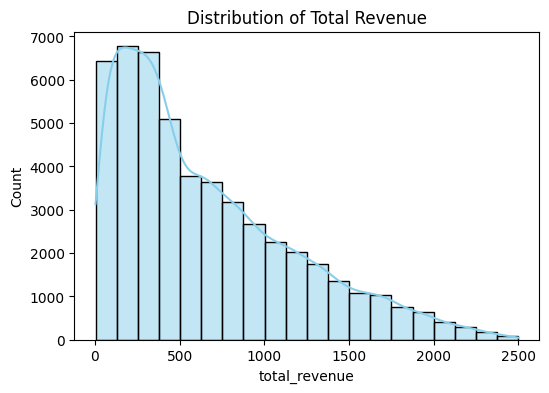

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(dataset['total_revenue'], kde=True, bins=20, color='skyblue')
plt.title("Distribution of Total Revenue")
plt.show()

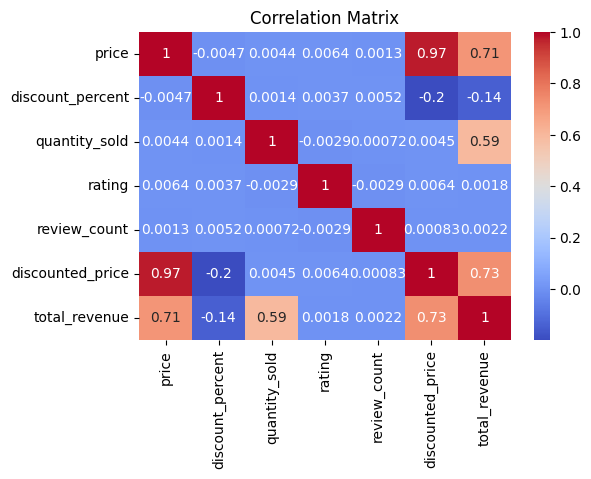

In [37]:
plt.figure(figsize=(6,4))
sns.heatmap(dataset[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [46]:
threshold=dataset['total_revenue'].median()
dataset['high rev']=np.where(dataset['total_revenue']>threshold,1,0)
print(dataset['high rev'].value_counts())

high rev
0    25000
1    25000
Name: count, dtype: int64


In [47]:
dataset_clean = dataset.drop(['order_id', 'order_date', 'product_id', 'total_revenue'], axis=1)


dataset_clean = pd.get_dummies(dataset_clean, columns=cat_cols, drop_first=True)

In [49]:
x=dataset_clean.drop('high rev',axis=1)
y=dataset_clean['high rev']

In [50]:
print(x)

        price  discount_percent  quantity_sold  rating  review_count  \
0      128.75                10              4     3.5           443   
1      302.60                20              5     3.7           475   
2      495.80                20              2     4.4           183   
3      371.95                15              4     5.0           212   
4      201.68                 0              4     4.6           308   
...       ...               ...            ...     ...           ...   
49995   26.99                 0              5     2.4           386   
49996  294.23                10              5     3.1             8   
49997  352.11                30              4     3.1           104   
49998  307.54                 5              1     1.8           316   
49999  253.44                30              1     2.1           464   

       discounted_price  product_category_Books  product_category_Electronics  \
0                115.88                    True       

In [51]:
print(y)

0        0
1        1
2        1
3        1
4        1
        ..
49995    0
49996    1
49997    1
49998    0
49999    0
Name: high rev, Length: 50000, dtype: int64


In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [55]:

from sklearn.linear_model import LogisticRegression 
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train, y_train)
y_pred_log = log_reg.predict(x_test)

In [57]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(x_train, y_train)
y_pred_dt = dt_clf.predict(x_test)

In [58]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rf_clf.fit(x_train, y_train)
y_pred_rf = rf_clf.predict(x_test)


In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

models = {'Logistic Regression': y_pred_log,
          'Decision Tree': y_pred_dt,
          'Random Forest': y_pred_rf}

for name, y_pred in models.items():
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    if name == 'Random Forest':
        print("ROC AUC:", roc_auc_score(y_test, rf_clf.predict_proba(x_test)[:,1]))
    print()

--- Logistic Regression ---
Accuracy: 0.9064
Confusion Matrix:
 [[4540  524]
 [ 412 4524]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      5064
           1       0.90      0.92      0.91      4936

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


--- Decision Tree ---
Accuracy: 1.0
Confusion Matrix:
 [[5064    0]
 [   0 4936]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5064
           1       1.00      1.00      1.00      4936

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


--- Random Forest ---
Accuracy: 0.9997
Confusion Matrix:
 [[5063    1]
 [   2 4934]]
Classification Report:
               

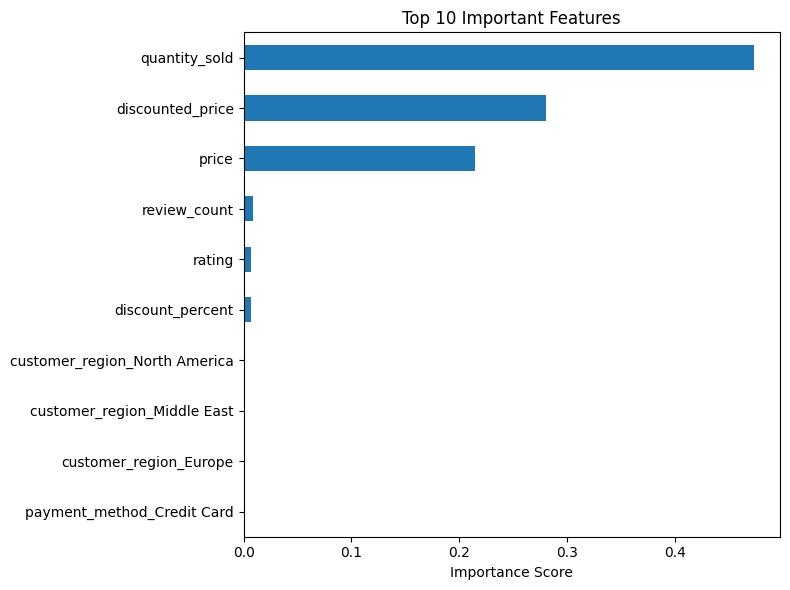

In [71]:


top10 = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()